In [45]:
# Load the file and pass it to SQLite
import kagglehub
import pandas as pd
import sqlite3
import os # Import the os module for path manipulation

# Download latest version from kaggle or from raw GitHub
#path_kaggle = kagglehub.dataset_download("shilongzhuang/telecom-customer-churn-by-maven-analytics")
path_github= "https://raw.githubusercontent.com/currotest/telecom-churn-prediction-strategy/main/data/"
csv_filename = "telecom_customer_churn.csv"
#df = pd.read_csv(os.path.join(path_kaggle, csv_filename))
df = pd.read_csv(os.path.join(path_github, csv_filename))

# 2. CRITICAL CLEANING FOR SQL: Names with spaces or parentheses break queries.
# This converts "Churn Category" to "Churn_Category"
df.columns = [c.replace(' ', '_').replace('(', '').replace(')', '') for c in df.columns]

# 3. Create in-memory database and load data
conn = sqlite3.connect(':memory:')
df.to_sql('churn_data', conn, index=False, if_exists='replace')

# 4. Helper function to execute SQL and view pretty results
def sql(query):
    return pd.read_sql(query, conn)

print("Database ready. Table 'churn_data' created.")

Database ready. Table 'churn_data' created.


In [2]:
# Explore the data
sql("PRAGMA table_info(churn_data);")
query_check = """
SELECT
    COUNT(Customer_ID) as total_customers,
    COUNT(*) as unique_customers,
    ROUND(SUM(Total_Revenue), 2) as total_historical_revenue,
    ROUND(AVG(Tenure_in_Months), 1) as average_tenure
FROM churn_data;
"""
sql(query_check)
# check that the customer_id column is unique

,total_customers,unique_customers,total_historical_revenue,average_tenure
0,7043,7043,21371131.69,32.4


In [3]:
# 1. Look for nulls
query_check = """
SELECT
    COUNT(*) as total_records,
    SUM(CASE WHEN Total_Revenue IS NULL THEN 1 ELSE 0 END) as nulls_revenue,
    SUM(CASE WHEN Churn_Reason IS NULL THEN 1 ELSE 0 END) as nulls_reason,
    -- Senior Trick: get the percentage of nulls
    ROUND(SUM(CASE WHEN Total_Revenue IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as pct_nulls_revenue
FROM churn_data;
"""
sql(query_check)

,total_records,nulls_revenue,nulls_reason,pct_nulls_revenue
0,7043,0,5174,0.0


In [4]:
# 3. Look for outliers
query_check = """
SELECT
    'Negative Revenue' as anomaly, COUNT(*) as cases FROM churn_data WHERE Total_Revenue < 0
UNION ALL
    -- People with 100 years of tenure (impossible)
SELECT
    'Excessive Tenure', COUNT(*) FROM churn_data WHERE Tenure_in_Months > 600
UNION ALL
    -- "Ghost" clients (they have revenue but no contract)
SELECT
    'Clients without Contract', COUNT(*) FROM churn_data WHERE Contract IS NULL AND Total_Revenue > 0;
"""
sql(query_check)

,anomaly,cases
0,Negative Revenue,0
1,Excessive Tenure,0
2,Clients without Contract,0


In [5]:
query_check_con_CTE = """
WITH Constants AS (
    SELECT COUNT(*) as grand_total FROM churn_data
)
SELECT
    Customer_Status,
    COUNT(*) as num_customers,
    COUNT(*) * 1.0 / (SELECT grand_total FROM Constants) as percentage
FROM churn_data
GROUP BY Customer_Status;
"""

sql(query_check_con_CTE)

,Customer_Status,num_customers,percentage
0,Churned,1869,0.265370
1,Joined,454,0.064461
2,Stayed,4720,0.670169


In [6]:
query_check_con_WINDOW = """
SELECT
    Customer_Status,
    COUNT(*) as num_customers,
    COUNT(*) * 100.0 / SUM(COUNT(*)) OVER() as percentage
FROM churn_data
GROUP BY Customer_Status;
"""

sql(query_check_con_WINDOW)

,Customer_Status,num_customers,percentage
0,Churned,1869,26.536987
1,Joined,454,6.446117
2,Stayed,4720,67.016896


In [7]:
# My first query
query_1 = """
WITH Revenue_Loss_Summary AS (
    SELECT
        Churn_Category,
        Churn_Reason,
        COUNT(Customer_ID) as Total_Customers,
        SUM(Total_Revenue) as Revenue_Lost
    FROM churn_data
    WHERE Customer_Status = 'Churned'
    GROUP BY 1, 2
)
SELECT
    Churn_Category,
    Churn_Reason,
    Total_Customers,
    ROUND(Revenue_Lost, 2) as Revenue_Lost_USD,
    -- HERE'S THE WOW: Window Function to get the % of the total without subqueries
    ROUND(Revenue_Lost * 100.0 / SUM(Revenue_Lost) OVER(), 2) as Pct_Total_Loss
FROM Revenue_Loss_Summary
ORDER BY Revenue_Lost DESC
LIMIT 10;
"""

# Execute and display
sql(query_1)

,Churn_Category,Churn_Reason,Total_Customers,Revenue_Lost_USD,Pct_Total_Loss
0,Competitor,Competitor made better offer,311,582822.20,15.82
1,Competitor,Competitor had better devices,313,579877.05,15.74
2,Attitude,Attitude of support person,220,404695.39,10.98
3,Competitor,Competitor offered more data,117,297568.21,8.08
4,Other,Don't know,130,256403.35,6.96
5,Competitor,Competitor offered higher download speeds,100,234145.69,6.35
6,Dissatisfaction,Product dissatisfaction,77,204875.74,5.56
7,Attitude,Attitude of service provider,94,174858.74,4.75
8,Price,Price too high,78,170170.43,4.62
9,Dissatisfaction,Network reliability,72,132443.67,3.59


In [8]:
# Analytical query
query_1 = """
WITH Churn_Metrics AS (
    SELECT
        Churn_Category,
        COUNT(Customer_ID) as total_customers,
        SUM(Total_Revenue) as lost_revenue
    FROM churn_data
    WHERE Customer_Status = 'Churned'
    GROUP BY Churn_Category
)
SELECT
    Churn_Category,
    total_customers,
    ROUND(lost_revenue, 2) as lost_revenue,
    -- % of total loss
    ROUND(lost_revenue * 100.0 / SUM(lost_revenue) OVER(), 2) as pct_of_total_loss,
    -- Importance ranking
    RANK() OVER(ORDER BY lost_revenue DESC) as importance_rank
FROM Churn_Metrics
ORDER BY lost_revenue DESC;

"""

# Execute and display
sql(query_1)

,Churn_Category,total_customers,lost_revenue,pct_of_total_loss,importance_rank
0,Competitor,841,1694413.15,45.99,1
1,Dissatisfaction,321,617979.26,16.77,2
2,Attitude,314,579554.13,15.73,3
3,Price,211,438124.14,11.89,4
4,Other,182,354389.14,9.62,5


In [9]:
# Analyze how much each customer pays compared to the average for their contract type
query_1 = """
WITH Base_Calculada AS (
    SELECT
        Customer_ID,
        Contract,
        Total_Revenue,
        AVG(Total_Revenue) OVER(PARTITION BY Contract) as avg_revenue_contract
    FROM churn_data
)
SELECT
    *,
    Total_Revenue - avg_revenue_contract as diff_vs_avg
FROM Base_Calculada
ORDER BY diff_vs_avg DESC
LIMIT 10;

"""

# Execute and display
sql(query_1)

,Customer_ID,Contract,Total_Revenue,avg_revenue_contract,diff_vs_avg
0,5287-QWLKY,Month-to-Month,10718.96,1707.060449,9011.899551
1,9090-SGQXL,Month-to-Month,10507.21,1707.060449,8800.149551
2,0979-PHULV,Month-to-Month,10374.80,1707.060449,8667.739551
3,5804-HYIEZ,Month-to-Month,10373.65,1707.060449,8666.589551
4,2632-UCGVD,Month-to-Month,10162.00,1707.060449,8454.939551
5,2615-YVMYX,Month-to-Month,10025.44,1707.060449,8318.379551
6,5502-RLUYV,Month-to-Month,10013.70,1707.060449,8306.639551
7,6067-NGCEU,Month-to-Month,9822.70,1707.060449,8115.639551
8,1469-LBJQJ,Month-to-Month,9724.03,1707.060449,8016.969551
9,1343-EHPYB,Month-to-Month,9686.85,1707.060449,7979.789551


In [10]:
# We prepare the view that we load into the dataframe, with a binary column
query_pre_python = """
WITH Agregados AS (
    SELECT
        *,

        CASE WHEN Customer_Status = 'Churned' THEN 1 ELSE 0 END AS Churn_Binary,
        -- Calculate revenue per month of tenure
        CASE WHEN Tenure_in_Months > 0 THEN Total_Revenue / Tenure_in_Months ELSE 0 END AS Monthly_LTV
    FROM churn_data
)
SELECT
    Customer_ID,
    Gender,
    Age,
    Married,
    City,
    Number_of_Referrals,
    Tenure_in_Months,
    Offer,
    Phone_Service,
    Internet_Type,
    Contract,
    Paperless_Billing,
    Payment_Method,
    Monthly_Charge,
    Total_Revenue,
    Monthly_LTV,
    Churn_Binary, -- Our target variable
    -- Window Function to see the customer's weight in their city
    ROUND(Total_Revenue * 100.0 / SUM(Total_Revenue) OVER(PARTITION BY City), 2) as Pct_Revenue_City
FROM Agregados;
"""


df_analisis = sql(query_pre_python)

In [11]:
# Data analysis, cleaning and preparation
df_analisis.head()
df_analisis.info()
df_analisis.describe().T
df_analisis['Total_Revenue'] = pd.to_numeric(df_analisis['Total_Revenue'], errors='coerce')
# Change NA to 0 and negative values to 0
money_columns = ['Monthly_Charge', 'Total_Revenue', 'Monthly_LTV']
df_analisis[money_columns]  = df_analisis[money_columns] .fillna(0)
df_analisis[money_columns] = df_analisis[money_columns].clip(lower=0)

contract_pivot_table = df_analisis.groupby('Contract').agg({
    'Churn_Binary': 'mean',        # This gives us the % of Churn per group
    'Total_Revenue': 'sum',        # Total revenue per contract
    'Customer_ID': 'count'         # How many customers there are
}).rename(columns={'Customer_ID': 'Total_Customers', 'Churn_Binary': 'Churn_Rate'})
contract_pivot_table.reset_index()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          7043 non-null   object 
 1   Gender               7043 non-null   object 
 2   Age                  7043 non-null   int64  
 3   Married              7043 non-null   object 
 4   City                 7043 non-null   object 
 5   Number_of_Referrals  7043 non-null   int64  
 6   Tenure_in_Months     7043 non-null   int64  
 7   Offer                3166 non-null   object 
 8   Phone_Service        7043 non-null   object 
 9   Internet_Type        5517 non-null   object 
 10  Contract             7043 non-null   object 
 11  Paperless_Billing    7043 non-null   object 
 12  Payment_Method       7043 non-null   object 
 13  Monthly_Charge       7043 non-null   float64
 14  Total_Revenue        7043 non-null   float64
 15  Monthly_LTV          7043 non-null   f

,Contract,Churn_Rate,Total_Revenue,Total_Customers
0,Month-to-Month,0.458449,6162488.22,3610
1,One Year,0.107097,6171794.31,1550
2,Two Year,0.025491,9036849.16,1883


In [12]:
# We create a combined metric: Referrals per month of tenure
# A customer with many referrals and little time is a "Star Promoter"
df_analisis['Referral_Rate'] = df_analisis['Number_of_Referrals'] / (df_analisis['Tenure_in_Months'] + 1)

# Do those who leave have a lower Referral_Rate?
print(df_analisis.groupby('Age')['Referral_Rate'].mean())

Age
19    0.120130
20    0.076393
21    0.137575
22    0.094904
23    0.070163
        ...   
76    0.180635
77    0.070307
78    0.103924
79    0.118206
80    0.076814
Name: Referral_Rate, Length: 62, dtype: float64


In [13]:
# 1. Analyze Pearson correlations, remove the own one with the drop
target = 'Churn_Binary'
correlations = df_analisis.corr(numeric_only=True)[target].drop(target).sort_values(ascending=False)

print("🎯 Numerical variables that most 'push' Churn:")
print(correlations)

🎯 Numerical variables that most 'push' Churn:
Monthly_Charge         0.188754
Monthly_LTV            0.170906
Age                    0.115760
Referral_Rate         -0.073523
Pct_Revenue_City      -0.180713
Total_Revenue         -0.223003
Number_of_Referrals   -0.286540
Tenure_in_Months      -0.352861
Name: Churn_Binary, dtype: float64


In [14]:
from sklearn.feature_selection import mutual_info_classif

# Convert categories to temporary numbers (Label Encoding) for the test
def codifico_categorias(df_input):
    df = df_input.copy()
    # Remove Customer_ID if present. I have already removed Customer ID which is not useful
    if 'Customer_ID' in df.columns:
        df = df.drop(columns=['Customer_ID'])

# Select only text columns
    cols_object = df.select_dtypes(include=['object']).columns
    for col in cols_object:
        df[col] = df[col].astype('category').cat.codes
    return df
# I can remove the target, observed, or response variable column
df_prepared=codifico_categorias(df_analisis)

# 2. Calculate Mutual Information with respect to the target, which is Churn Binary. I need to set a value
# for random_state to make it deterministic, so that when the code is executed again, the random noise is exactly the same
importances = mutual_info_classif(df_prepared, df_analisis[target], random_state=42)

# 3. Display sorted results
mi_results = pd.Series(importances, index=df_prepared.columns).sort_values(ascending=False)
print("🧐 Categorical Variable Dependence (Mutual Info):")
print(mi_results)

🧐 Categorical Variable Dependence (Mutual Info):
Churn_Binary           0.578883
Contract               0.113542
Tenure_in_Months       0.068097
Number_of_Referrals    0.067978
Referral_Rate          0.059521
Internet_Type          0.050996
Monthly_Charge         0.047103
Total_Revenue          0.040437
Offer                  0.034434
Payment_Method         0.032301
Pct_Revenue_City       0.031776
City                   0.025627
Monthly_LTV            0.017295
Paperless_Billing      0.017275
Married                0.013580
Gender                 0.006548
Age                    0.003597
Phone_Service          0.000000
dtype: float64


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train a fast model (Random Forest)
X = df_prepared.drop(columns=[target])
y = df_prepared[target]
# And I also leave my training and test data prepared
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
# I decide whether to train with all or with train
#model.fit(X, y)
model.fit(X_train, y_train)

# Get variable importances
importancias_globales = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Define the probability threshold to be used
my_threshold = 0.4

# Calculate the Prob that the model gives me[:, 1] means that we want the probability of class 1 (which is Churn)
model_probs = model.predict_proba(X_test)[:, 1]

# Evaluate the model (by default, it assigns 0 or 1 with threshold 0.5, I can change that)
#model_pred=model.predict(X_test)
model_pred= (model_probs >=my_threshold).astype(int)
print(f"🎯 Model Accuracy: {accuracy_score(y_test, model_pred)}")

print("🚀 FINAL IMPORTANCE RANKING (The 'Wow' system):")
print(importancias_globales.head(10))
print(classification_report(y_test, model_pred, target_names=['No Churn', 'Churn']))

🎯 Model Accuracy: 0.8360539389638041
🚀 FINAL IMPORTANCE RANKING (The 'Wow' system):
Contract               0.119601
Monthly_Charge         0.102782
Total_Revenue          0.098142
Tenure_in_Months       0.097362
Age                    0.093883
Pct_Revenue_City       0.091513
Monthly_LTV            0.081084
City                   0.072811
Number_of_Referrals    0.064963
Internet_Type          0.048336
dtype: float64
              precision    recall  f1-score   support

    No Churn       0.91      0.87      0.89      1062
       Churn       0.65      0.73      0.69       347

    accuracy                           0.84      1409
   macro avg       0.78      0.80      0.79      1409
weighted avg       0.84      0.84      0.84      1409



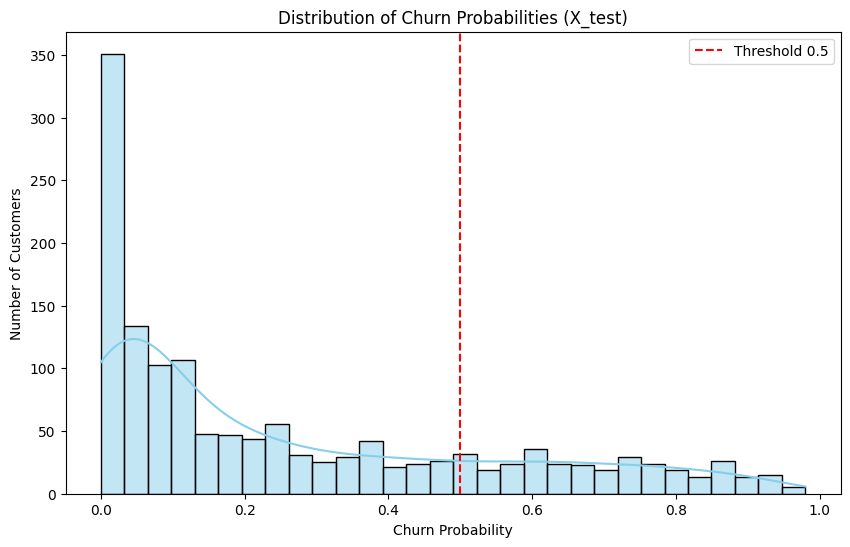

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(model_probs, bins=30, kde=True, color='skyblue')
plt.axvline(0.5, color='red', linestyle='--', label='Threshold 0.5')
plt.title('Distribution of Churn Probabilities (X_test)')
plt.xlabel('Churn Probability')
plt.ylabel('Number of Customers')
plt.legend()
plt.savefig('churn_probabilities.png') # Save the figure before showing
plt.show()

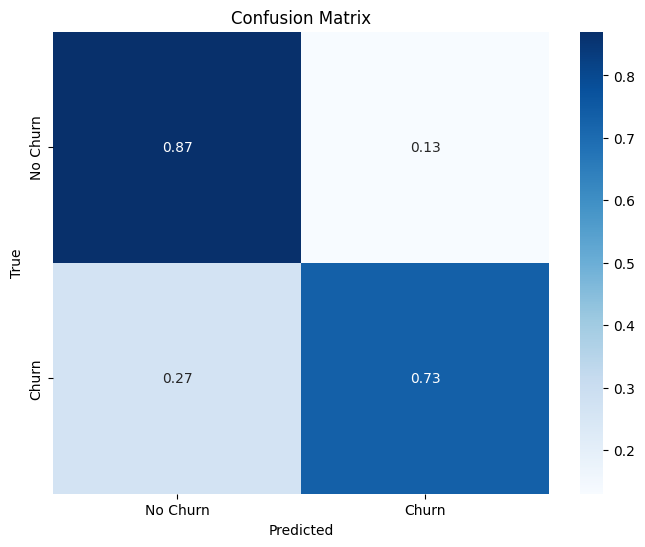

In [36]:
cm = confusion_matrix(y_test, model_pred, normalize='true')
plt.figure(figsize=(8, 6))
# If I use sns, almost everything fits in one instruction, including the values
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()


In [18]:
cm

array([[0.8700565 , 0.1299435 ],
       [0.26801153, 0.73198847]])

⏳ Calculating PDP... (this may take a few seconds)
Code dictionary: {0: 'Month-to-Month', 1: 'One Year', 2: 'Two Year'}


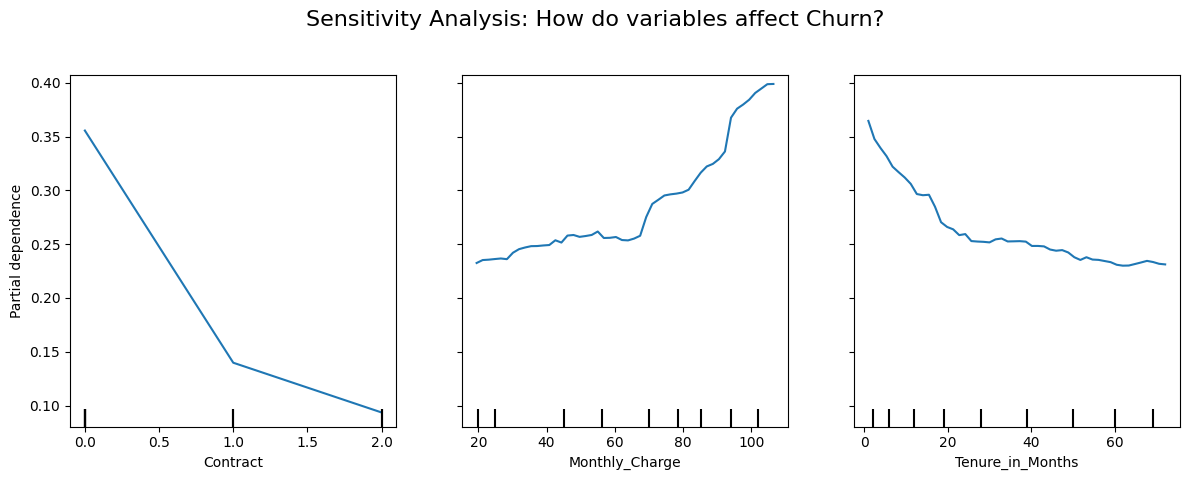

In [37]:
from sklearn.inspection import PartialDependenceDisplay
# Partial Dependence Plot.
# We select the most important numerical variables according to your ranking
# (Adjust names if they are different in your dataset)
features_to_plot = ['Contract','Monthly_Charge', 'Tenure_in_Months']

print("⏳ Calculating PDP... (this may take a few seconds)")

# Configure the plot
fig, ax = plt.subplots(figsize=(12, 5))

# Generate the PDP
PartialDependenceDisplay.from_estimator(
    estimator=model,
    X=X_train,              # We use training data
    features=features_to_plot,
    grid_resolution=50,     # Curve smoothness
    ax=ax
)
# First, check which number each contract is so you don't make a mistake
mapping = dict(enumerate(df_analisis['Contract'].astype('category').cat.categories))
print(f"Code dictionary: {mapping}")
plt.suptitle('Sensitivity Analysis: How do variables affect Churn?', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('sensitive_analysis.png')
plt.show()


In [20]:
print(model.classes_)

[0 1]


Prob. churn explainer= 0.2691444799432019
Prob. churn dataset= 0.2653698707936959


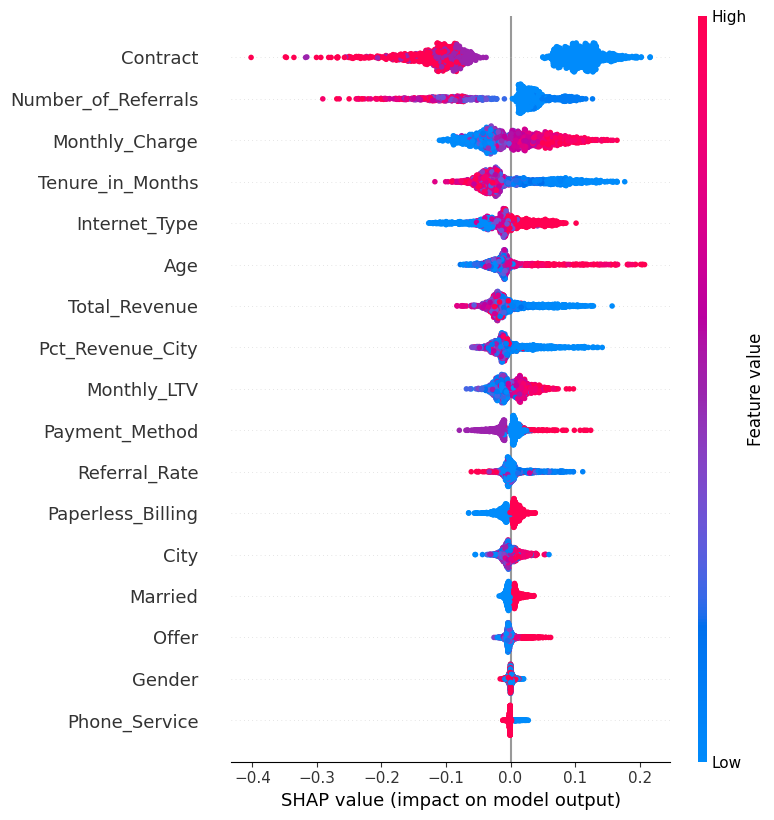

<Figure size 640x480 with 0 Axes>

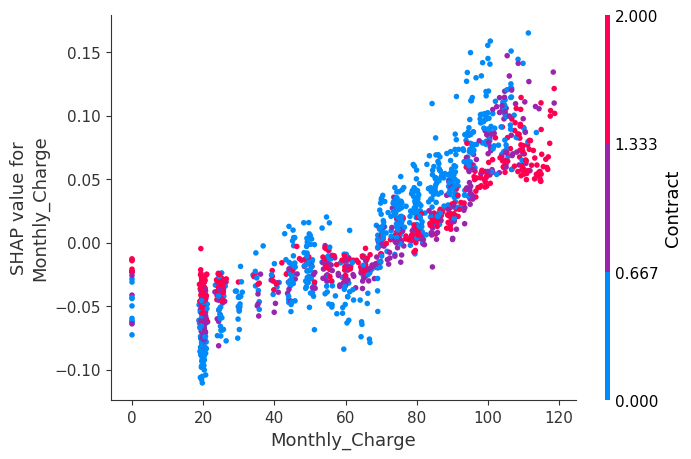

<Figure size 640x480 with 0 Axes>

In [41]:
import shap
import matplotlib.pyplot as plt # Import matplotlib for saving plots

# 1. Create the specific "Explainer" for tree models (very fast)
explainer = shap.TreeExplainer(model)
# This is the base value, the average churn probability of the model
print(f"Prob. churn explainer= {explainer.expected_value[1]}")
print(f"Prob. churn dataset= {df_analisis['Churn_Binary'].mean()}")
# 2. Calculate SHAP values for the test set
# We use the test to see how the model behaves with data it "doesn't know"
shap_values = explainer.shap_values(X_test)

# 3. Visualization: The Summary Plot (Beeswarm)
# This is the graph to include in the final report
shap.summary_plot(shap_values[:, :, 1], X_test)
# Get the current figure and save it
fig_summary = plt.gcf()
fig_summary.savefig('shap_summary_plot.png', bbox_inches='tight')

# 4. Visualization. This graph will tell you the "Security Price"
shap.dependence_plot("Monthly_Charge", shap_values[:, :, 1], X_test)
# Get the current figure and save it
fig_dependence = plt.gcf()
fig_dependence.savefig('shap_dependence_plot_monthly_charge.png', bbox_inches='tight')


In [22]:
explainer.expected_value[1]
print(f"Prob. churn explainer= {explainer.expected_value[1]}")
print(f"Prob. churn explainer= {df_analisis['Churn_Binary'].mean()}")
# Create a dictionary to see the correspondence
mapping = dict(enumerate(df_analisis['Contract'].astype('category').cat.categories))
print(f"The map is: {mapping}")

Prob. churn explainer= 0.2691444799432019
Prob. churn explainer= 0.2653698707936959
The map is: {0: 'Month-to-Month', 1: 'One Year', 2: 'Two Year'}


In [23]:
from sklearn.tree import DecisionTreeClassifier, export_text

# 2. Create a temporary label: 1 if the risk is > my_threshold, 0 if not.
# This allows us to focus ONLY on critical cases.
high_risk_label = (model_probs > my_threshold).astype(int)
print(f"Number of samples : {high_risk_label.shape[0]}")
print(f"Number of 1 values : {high_risk_label.sum()}")
# 3. Train a small tree to explain that "High Risk"
surrogate_tree = DecisionTreeClassifier(max_depth=3)
surrogate_tree.fit(X_test, high_risk_label)

# 4. Evaluate how good this surrogate is compared to the original RandomForest model
print(f"Tree Fidelity: {surrogate_tree.score(X_test, high_risk_label):.2%}")
# 5. Print the rules in plain text!
rules = export_text(surrogate_tree, feature_names=list(X_test.columns))
print(rules)

Number of samples : 1409
Number of 1 values : 385
Tree Fidelity: 87.08%
|--- Contract <= 0.50
|   |--- Number_of_Referrals <= 2.50
|   |   |--- Internet_Type <= -0.50
|   |   |   |--- class: 0
|   |   |--- Internet_Type >  -0.50
|   |   |   |--- class: 1
|   |--- Number_of_Referrals >  2.50
|   |   |--- Tenure_in_Months <= 1.50
|   |   |   |--- class: 1
|   |   |--- Tenure_in_Months >  1.50
|   |   |   |--- class: 0
|--- Contract >  0.50
|   |--- Monthly_Charge <= 94.08
|   |   |--- Total_Revenue <= 8304.25
|   |   |   |--- class: 0
|   |   |--- Total_Revenue >  8304.25
|   |   |   |--- class: 0
|   |--- Monthly_Charge >  94.08
|   |   |--- Pct_Revenue_City <= 1.23
|   |   |   |--- class: 0
|   |   |--- Pct_Revenue_City >  1.23
|   |   |   |--- class: 0



In [24]:
from sklearn.inspection import permutation_importance

# The stress test: we shuffle the data 10 times for each variable
result10 = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
result50 = permutation_importance(model, X_test, y_test, n_repeats=50, random_state=42)

# Order the results
perm_importances = pd.Series(result10.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_importances_50 = pd.Series(result50.importances_mean, index=X_test.columns)

# Create a DataFrame to compare both results
comparison_df = pd.DataFrame({
    'Importance_n10': perm_importances,
    'Importance_n50': perm_importances_50
}).sort_values(by='Importance_n10', ascending=False)

print("--- Permutation Importance Comparison (10 vs 50 repetitions) ---")
print(comparison_df.head(10))

--- Permutation Importance Comparison (10 vs 50 repetitions) ---
                     Importance_n10  Importance_n50
Contract                   0.063875        0.062243
Number_of_Referrals        0.024911        0.024684
Monthly_Charge             0.021859        0.020724
Age                        0.020298        0.020014
Tenure_in_Months           0.010717        0.010149
Monthly_LTV                0.009013        0.007268
Internet_Type              0.005678        0.004670
Pct_Revenue_City           0.003691        0.003903
Total_Revenue              0.003549        0.004542
Paperless_Billing          0.001348        0.002257


In [25]:
# Quantify economic value of at-risk customers
# 1. Apply the model to the entire Dataset (I have to prepare the data as I did with X_test)
df_full_original = df_analisis.drop(columns=['Customer_ID', 'Churn_Binary'])
# Apply category encoding to df_full
df_full_encoded = codifico_categorias(df_full_original.copy())

# Ensure that the columns of df_full_encoded match those on which the model was trained (X)
# and are in the same order.
X_columns_order = X.columns # X is the DataFrame used to train the model
df_full_encoded = df_full_encoded[X_columns_order]
full_prob = model.predict_proba(df_full_encoded)[:, 1]

# 2. Create a df copy to work with and add the prob
df_analisis_con_prob=df_analisis.copy()
df_analisis_con_prob['Prob_Churn'] = full_prob

# 3. Create DF only with target customers
df_riesgo = df_analisis_con_prob[df_analisis_con_prob['Prob_Churn'] > my_threshold].copy()

In [26]:
# --- BUSINESS PARAMETERS (Adjust according to your reality) ---
tasa_conversion = 0.30  # 30% of contacted customers agree to stay
descuento_incentivo = 0.15  # We give them a 15% discount for a 1-year contract
# --------------------------------------------------------

# 5. CALCULATIONS
num_clientes_a_intervenir = len(df_riesgo)
ingreso_mensual_en_riesgo = df_riesgo['Monthly_Charge'].sum()

# Money we actually recover after the campaign
dinero_salvado_anual = (ingreso_mensual_en_riesgo * tasa_conversion) * 12

# What it costs us to give the discount to those who accept
coste_descuentos = (ingreso_mensual_en_riesgo * tasa_conversion) * 0.15 * 12

# FINAL ROI
beneficio_neto = dinero_salvado_anual - coste_descuentos
roi_porcentaje = (beneficio_neto / coste_descuentos) * 100

print(f"--- TOTAL IMPACT ANALYSIS ---")
print(f"Customers to contact (>40% risk): {num_clientes_a_intervenir}")
print(f"Monthly revenue at risk: {ingreso_mensual_en_riesgo:,.2f}€")
print(f"Revenue recovered (Annual): {dinero_salvado_anual:,.2f}€")
print(f"Cost of retention: {coste_descuentos:,.2f}€")
print(f"NET PROFIT FOR THE COMPANY: {beneficio_neto:,.2f}€")
print(f"Campaign ROI: {roi_porcentaje:.2f}%")

--- TOTAL IMPACT ANALYSIS ---
Customers to contact (>40% risk): 1911
Monthly revenue at risk: 139,874.85€
Revenue recovered (Annual): 503,549.46€
Cost of retention: 75,532.42€
NET PROFIT FOR THE COMPANY: 428,017.04€
Campaign ROI: 566.67%


In [27]:
# Filter the 10 customers who would make us lose the most money if they leave tomorrow
top_10_fuga = df_riesgo.sort_values(by='Prob_Churn', ascending=False).head(10)

print("--- TOP 10 CRITICAL CUSTOMERS BY VALUE ---")
print(top_10_fuga[['Customer_ID', 'Monthly_Charge', 'Prob_Churn']])

--- TOP 10 CRITICAL CUSTOMERS BY VALUE ---
     Customer_ID  Monthly_Charge  Prob_Churn
2988  0390-DCFDQ           70.45         1.0
4360  1833-VGRUM           74.20         1.0
3949  8510-AWCXC          100.80         1.0
1100  5539-TMZLF           69.75         1.0
5312  8058-INTPH           79.65         1.0
5974  1415-YFWLT           89.30         1.0
5350  9497-QCMMS           93.55         1.0
1523  9300-AGZNL           94.00         1.0
4637  1396-QWFBJ           74.05         1.0
5423  4550-EVXNY           69.65         1.0


In [30]:
import plotly.graph_objects as go
import plotly.io as pio
# Sankey Diagram
# Simplify for the graph: Contract -> Churn

df_analisis_con_prob['Churn_Label'] = df_analisis_con_prob['Churn_Binary'].map({1: 'Churn', 0: 'No churn'})

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15, thickness = 20, line = dict(color = "black", width = 0.5),
      label = ["Month-to-Month", "One Year", "Two Year", "No churn", "CHURN"],
      color = "blue"
    ),
    link = dict(
      # Define origin, destination and value (Monthly_Charge sum)
      source = [0, 0, 1, 1, 2, 2],
      target = [3, 4, 3, 4, 3, 4],
      value = [
          df_analisis_con_prob[(df_analisis_con_prob['Contract'] == 'Month-to-Month') & (df_analisis_con_prob['Churn_Label'] == 'No churn')]['Monthly_Charge'].sum(),
          df_analisis_con_prob[(df_analisis_con_prob['Contract'] == 'Month-to-Month') & (df_analisis_con_prob['Churn_Label'] == 'Churn')]['Monthly_Charge'].sum(),
          df_analisis_con_prob[(df_analisis_con_prob['Contract'] == 'One Year') & (df_analisis_con_prob['Churn_Label'] == 'No churn')]['Monthly_Charge'].sum(),
          df_analisis_con_prob[(df_analisis_con_prob['Contract'] == 'One Year') & (df_analisis_con_prob['Churn_Label'] == 'Churn')]['Monthly_Charge'].sum(),
          df_analisis_con_prob[(df_analisis_con_prob['Contract'] == 'Two Year') & (df_analisis_con_prob['Churn_Label'] == 'No churn')]['Monthly_Charge'].sum(),
          df_analisis_con_prob[(df_analisis_con_prob['Contract'] == 'Two Year') & (df_analisis_con_prob['Churn_Label'] == 'Churn')]['Monthly_Charge'].sum()
      ]
  ))])

fig.update_layout(title_text="Revenue Flow by Contract Type and Destination", font_size=10)
fig.show()



In [31]:
import plotly.express as px
# Scatter
# Create a graph where each point is a customer
fig = px.scatter(df_analisis_con_prob,
                 x="Prob_Churn",
                 y="Monthly_Charge",
                 color="Contract",
                 size=df_analisis_con_prob['Monthly_Charge'].abs(), # The more they pay, the larger the point
                 hover_data=['Customer_ID'],
                 title="Decision Matrix: Risk vs. Monthly Value",
                 labels={'Probabilidad_Churn': 'Churn Probability', 'Monthly_Charge': 'Monthly Revenue'},
                 color_discrete_map={'Month-to-month': '#E74C3C', 'One year': '#F1C40F', 'Two year': '#2ECC71'})

# Add a line at my_threshold (your action threshold)
fig.add_vline(x=my_threshold, line_dash="dash", line_color="red", annotation_text="ACTION THRESHOLD")

fig.show()

